<a href="https://colab.research.google.com/github/Hasibur02/ASD-Detection-Deep-Learning/blob/main/AlexNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ==========================================================
# ASD Detection Using Deep Learning & Transfer Learning
# 01. IMPORTS
# ==========================================================

In [ ]:
# ============================
# IMPORTS
# ============================

import os
import random
import warnings

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torchvision.models import regnet_y_800mf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

print("=" * 60)
print("IMPORTS COMPLETED")
print("=" * 60)

print("PyTorch     :", torch.__version__)
print("TorchVision :", torchvision.__version__)
print("NumPy       :", np.__version__)

IMPORTS COMPLETED
PyTorch     : 2.11.0+cu128
TorchVision : 0.26.0+cu128
NumPy       : 2.0.2


# ==========================================================
# Device Configuration (Colab + Tesla T4 Optimized)
# ==========================================================

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(
        f"Memory: "
        f"{torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB"
    )

torch.backends.cudnn.benchmark = True

Using device: cuda
GPU: Tesla T4
Memory: 14.6 GB



# ==========================================================
#03. Dataset Setup
#==========================================================

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/AutismDataset"

train_dir = os.path.join(BASE_DIR, "train")
valid_dir = os.path.join(BASE_DIR, "valid")
test_dir = os.path.join(BASE_DIR, "test")

print("Dataset Path:", BASE_DIR)

Mounted at /content/drive
Dataset Path: /content/drive/MyDrive/AutismDataset


In [ ]:
def read_img(directory):

    image_paths = []
    labels = []

    for root, dirs, files in os.walk(directory):

        for image_file in sorted(files):

            if not image_file.lower().endswith(
                (".jpg", ".jpeg", ".png", ".bmp", ".webp")
            ):
                continue

            image_path = os.path.join(root, image_file)

            folder_name = os.path.basename(root).lower()
            file_name = image_file.lower()

            if folder_name == "autistic":
                label = "Autistic"

            elif folder_name in ["non_autistic", "non-autistic"]:
                label = "Non_Autistic"

            elif file_name.startswith("autistic"):
                label = "Autistic"

            elif file_name.startswith("non_autistic"):
                label = "Non_Autistic"

            else:
                continue

            image_paths.append(image_path)
            labels.append(label)

    return pd.DataFrame({
        "image_path": image_paths,
        "label": labels
    })

In [ ]:
import pandas as pd
train_df = read_img(train_dir)
valid_df = read_img(valid_dir)
test_df = read_img(test_dir)

print("Training:", len(train_df))
print("Validation:", len(valid_df))
print("Testing:", len(test_df))

Training: 2542
Validation: 100
Testing: 300


# ==========================================================
# 04. DATASET STATISTICS
# ==========================================================

In [ ]:
datasets = {
    "Training": train_df,
    "Validation": valid_df,
    "Testing": test_df
}

print("=" * 60)
print("DATASET STATISTICS")
print("=" * 60)

# ----------------------------
# Dataset Size
# ----------------------------

for name, df in datasets.items():
    print(f"{name} Samples: {len(df):,}")

total_samples = sum(len(df) for df in datasets.values())

print(f"Total Samples: {total_samples:,}")


# ----------------------------
# Class Distribution
# ----------------------------

print("\n" + "=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)

for name, df in datasets.items():

    print(f"\n{name} Set:")
    print(df["label"].value_counts())

    print("\nPercentage:")
    print(
        (df["label"].value_counts(normalize=True) * 100)
        .round(2)
        .astype(str)
        + "%"
    )


# ----------------------------
# Missing Values
# ----------------------------

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)

for name, df in datasets.items():

    print(f"\n{name}:")
    print(df.isnull().sum())


print("\n" + "=" * 60)
print("Dataset statistics completed.")
print("=" * 60)

DATASET STATISTICS
Training Samples: 2,542
Validation Samples: 100
Testing Samples: 300
Total Samples: 2,942

CLASS DISTRIBUTION

Training Set:
label
Non_Autistic    1272
Autistic        1270
Name: count, dtype: int64

Percentage:
label
Non_Autistic    50.04%
Autistic        49.96%
Name: proportion, dtype: object

Validation Set:
label
Autistic        50
Non_Autistic    50
Name: count, dtype: int64

Percentage:
label
Autistic        50.0%
Non_Autistic    50.0%
Name: proportion, dtype: object

Testing Set:
label
Autistic        150
Non_Autistic    150
Name: count, dtype: int64

Percentage:
label
Autistic        50.0%
Non_Autistic    50.0%
Name: proportion, dtype: object

MISSING VALUES

Training:
image_path    0
label         0
dtype: int64

Validation:
image_path    0
label         0
dtype: int64

Testing:
image_path    0
label         0
dtype: int64

Dataset statistics completed.


# ==========================================================
# 05. IMAGE TRANSFORMATIONS
# ==========================================================

In [ ]:

from torchvision import transforms
from torchvision.transforms import InterpolationMode


# ==========================================================
# CNN Training Transform
# ==========================================================

train_transform_cnn = transforms.Compose([

    transforms.RandomResizedCrop(
        size=224,
        scale=(0.8, 1.0),
        interpolation=InterpolationMode.BICUBIC
    ),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(degrees=10),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),

    transforms.RandomErasing(
        p=0.2,
        scale=(0.02, 0.1)
    )
])


# ==========================================================
# ViT Training Transform
# ==========================================================

train_transform_vit = transforms.Compose([

    transforms.RandomResizedCrop(
        size=224,
        scale=(0.85, 1.0),
        interpolation=InterpolationMode.BICUBIC
    ),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(degrees=5),

    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ==========================================================
# Validation / Test Transform
# ==========================================================

val_test_transform = transforms.Compose([

    transforms.Resize(
        (224, 224),
        interpolation=InterpolationMode.BICUBIC
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


print("Image transformations created successfully.")

Image transformations created successfully.


# ==========================================================
# 06. Hyperparameters
# ==========================================================

In [ ]:
# ==========================================================
# 06. HYPERPARAMETERS
# ==========================================================

# ----------------------------
# Training
# ----------------------------

NUM_EPOCHS = 25

LEARNING_RATE = 3e-5

WEIGHT_DECAY = 0.05

NUM_CLASSES = 2


# ----------------------------
# Batch Sizes
# ----------------------------

BATCH_SIZE = 32


# ----------------------------
# DataLoader
# ----------------------------

NUM_WORKERS = 2

PIN_MEMORY = torch.cuda.is_available()


# ----------------------------
# Early Stopping
# ----------------------------

PATIENCE = 7


# ----------------------------
# Reproducibility
# ----------------------------

RANDOM_SEED = 42


# ----------------------------
# Display
# ----------------------------

print("=" * 60)
print("HYPERPARAMETERS")
print("=" * 60)

print(f"Epochs          : {NUM_EPOCHS}")
print(f"Learning Rate   : {LEARNING_RATE}")
print(f"Weight Decay    : {WEIGHT_DECAY}")
print(f"Number of Classes: {NUM_CLASSES}")
print(f"Batch Size      : {BATCH_SIZE}")
print(f"Workers         : {NUM_WORKERS}")
print(f"Pin Memory      : {PIN_MEMORY}")
print(f"Early Stopping  : {PATIENCE}")
print(f"Random Seed     : {RANDOM_SEED}")

print("=" * 60)

HYPERPARAMETERS
Epochs          : 25
Learning Rate   : 3e-05
Weight Decay    : 0.05
Number of Classes: 2
Batch Size      : 32
Workers         : 2
Pin Memory      : True
Early Stopping  : 7
Random Seed     : 42


# ==========================================================
# 7. Dataset Class & DataLoaders
# ==========================================================

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from PIL import Image


# ==========================================================
# Hyperparameters
# ==========================================================

BATCH_SIZE = 32
NUM_WORKERS = 2

PIN_MEMORY = torch.cuda.is_available()


# ==========================================================
# CNN Validation / Test Transform
# ==========================================================

val_test_transform_cnn = transforms.Compose([

    transforms.Resize(
        (224, 224),
        interpolation=InterpolationMode.BICUBIC
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ==========================================================
# Autism Dataset Class
# ==========================================================

class AutismDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None,
        label_encoder=None,
        fit_label_encoder=False
    ):

        self.data = dataframe.reset_index(drop=True)

        self.transform = transform

        self.image_paths = self.data["image_path"].values


        # --------------------------------------------------
        # Label Encoding
        # --------------------------------------------------

        if label_encoder is None:

            self.label_encoder = LabelEncoder()

            if fit_label_encoder:

                self.labels = self.label_encoder.fit_transform(
                    self.data["label"]
                )

            else:

                raise ValueError(
                    "Set fit_label_encoder=True for training dataset"
                )

        else:

            self.label_encoder = label_encoder

            self.labels = self.label_encoder.transform(
                self.data["label"]
            )


    # ------------------------------------------------------
    # Number of Samples
    # ------------------------------------------------------

    def __len__(self):

        return len(self.data)


    # ------------------------------------------------------
    # Load One Image
    # ------------------------------------------------------

    def __getitem__(self, idx):

        image_path = self.image_paths[idx]

        try:

            image = Image.open(
                image_path
            ).convert("RGB")

        except Exception:

            print("Error loading:", image_path)

            image = Image.new(
                "RGB",
                (224, 224),
                "black"
            )


        # Apply transformation

        if self.transform:

            image = self.transform(image)


        # Label

        label = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )


        return image, label


    # ------------------------------------------------------
    # Label Encoder
    # ------------------------------------------------------

    def get_label_encoder(self):

        return self.label_encoder


    # ------------------------------------------------------
    # Class Names
    # ------------------------------------------------------

    def get_class_names(self):

        return self.label_encoder.classes_


# ==========================================================
# DataLoader Creation Function
# ==========================================================

def create_dataloaders(
    train_df,
    val_df,
    test_df,
    train_transform,
    val_test_transform,
    batch_size=32,
    num_workers=2
):


    # ======================================================
    # Training Dataset
    # ======================================================

    train_dataset = AutismDataset(

        train_df,

        transform=train_transform,

        fit_label_encoder=True
    )


    # Get Label Encoder

    label_encoder = train_dataset.get_label_encoder()


    # ======================================================
    # Validation Dataset
    # ======================================================

    val_dataset = AutismDataset(

        val_df,

        transform=val_test_transform,

        label_encoder=label_encoder
    )


    # ======================================================
    # Test Dataset
    # ======================================================

    test_dataset = AutismDataset(

        test_df,

        transform=val_test_transform,

        label_encoder=label_encoder
    )


    # ======================================================
    # DataLoader Arguments
    # ======================================================

    loader_args = {

        "batch_size": batch_size,

        "num_workers": num_workers,

        "pin_memory": PIN_MEMORY
    }


    if num_workers > 0:

        loader_args["persistent_workers"] = True

        loader_args["prefetch_factor"] = 2


    # ======================================================
    # Training DataLoader
    # ======================================================

    train_loader = DataLoader(

        train_dataset,

        shuffle=True,

        drop_last=True,

        **loader_args
    )


    # ======================================================
    # Validation DataLoader
    # ======================================================

    val_loader = DataLoader(

        val_dataset,

        shuffle=False,

        **loader_args
    )


    # ======================================================
    # Test DataLoader
    # ======================================================

    test_loader = DataLoader(

        test_dataset,

        shuffle=False,

        **loader_args
    )


    # ======================================================
    # Summary
    # ======================================================

    print("=" * 60)
    print("DATALOADER SUMMARY")
    print("=" * 60)

    print(
        f"Training Images   : {len(train_dataset):,}"
    )

    print(
        f"Validation Images : {len(val_dataset):,}"
    )

    print(
        f"Testing Images    : {len(test_dataset):,}"
    )

    print()

    print(
        f"Batch Size        : {batch_size}"
    )

    print(
        f"Workers           : {num_workers}"
    )

    print(
        f"Pin Memory        : {PIN_MEMORY}"
    )

    print()

    print("Classes:")
    print(label_encoder.classes_)

    print("=" * 60)


    return (
        train_loader,
        val_loader,
        test_loader,
        label_encoder
    )


# ==========================================================
# 7A. Create RegNet CNN DataLoaders
# ==========================================================

train_loader_cnn, val_loader_cnn, test_loader_cnn, label_encoder = create_dataloaders(

    train_df,
    valid_df,
    test_df,

    train_transform_cnn,
    val_test_transform_cnn,

    batch_size=32,
    num_workers=2
)


print("=" * 60)
print("RegNetY-800MF DataLoaders Created")
print("=" * 60)

print(
    f"Training samples   : "
    f"{len(train_loader_cnn.dataset):,}"
)

print(
    f"Validation samples : "
    f"{len(val_loader_cnn.dataset):,}"
)

print(
    f"Test samples       : "
    f"{len(test_loader_cnn.dataset):,}"
)

print()

print(
    f"Training batches   : "
    f"{len(train_loader_cnn):,}"
)

print(
    f"Validation batches : "
    f"{len(val_loader_cnn):,}"
)

print(
    f"Test batches       : "
    f"{len(test_loader_cnn):,}"
)

print()

print(
    f"Classes            : "
    f"{list(label_encoder.classes_)}"
)

print(
    f"Number of classes  : "
    f"{len(label_encoder.classes_)}"
)


# ==========================================================
# 7B. Verify CNN Batch
# ==========================================================

images, labels = next(
    iter(train_loader_cnn)
)

print()
print("RegNetY-800MF Batch Verification")
print("=" * 60)

print(
    f"Image batch shape : "
    f"{images.shape}"
)

print(
    f"Label shape       : "
    f"{labels.shape}"
)

print("=" * 60)


DATALOADER SUMMARY
Training Images   : 2,542
Validation Images : 100
Testing Images    : 300

Batch Size        : 32
Workers           : 2
Pin Memory        : True

Classes:
['Autistic' 'Non_Autistic']
RegNetY-800MF DataLoaders Created
Training samples   : 2,542
Validation samples : 100
Test samples       : 300

Training batches   : 79
Validation batches : 4
Test batches       : 10

Classes            : ['Autistic', 'Non_Autistic']
Number of classes  : 2

RegNetY-800MF Batch Verification
Image batch shape : torch.Size([32, 3, 224, 224])
Label shape       : torch.Size([32])


# ==========================================================
# 8. ModelTrainer Class Definition
# ==========================================================

In [ ]:
# ============================================================
# SECTION 8 — MODEL TRAINER
# ============================================================

import copy
import time

import torch
import torch.nn as nn

from tqdm.auto import tqdm
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.amp import autocast, GradScaler


class ModelTrainer:

    def __init__(
        self,
        model,
        train_loader,
        val_loader,
        device
    ):

        self.model = model.to(device)

        self.train_loader = train_loader
        self.val_loader = val_loader

        self.device = device

        # Training history
        self.train_losses = []
        self.val_losses = []

        self.train_accuracies = []
        self.val_accuracies = []


    # ========================================================
    # TRAIN MODEL
    # ========================================================

    def train_model(
        self,
        num_epochs=25,
        lr=3e-5,
        weight_decay=0.05,
        patience=7,
        model_name="RegNetY-800MF"
    ):

        # ----------------------------------------------------
        # Loss Function
        # ----------------------------------------------------

        criterion = nn.CrossEntropyLoss(
            label_smoothing=0.1
        )


        # ----------------------------------------------------
        # Optimizer
        # ----------------------------------------------------

        optimizer = AdamW(
            self.model.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )


        # ----------------------------------------------------
        # Learning Rate Scheduler
        # ----------------------------------------------------

        scheduler = CosineAnnealingLR(
            optimizer,
            T_max=num_epochs
        )


        # ----------------------------------------------------
        # Mixed Precision
        # ----------------------------------------------------

        scaler = GradScaler(
            "cuda",
            enabled=(self.device.type == "cuda")
        )


        # ----------------------------------------------------
        # Best Model Tracking
        # ----------------------------------------------------

        best_val_acc = 0.0

        best_weights = copy.deepcopy(
            self.model.state_dict()
        )

        patience_counter = 0


        # ----------------------------------------------------
        # Training Start
        # ----------------------------------------------------

        start_time = time.time()

        print("=" * 60)
        print(f"TRAINING: {model_name}")
        print("=" * 60)

        print(f"Epochs       : {num_epochs}")
        print(f"Learning Rate: {lr}")
        print(f"Weight Decay : {weight_decay}")
        print(f"Patience     : {patience}")
        print(f"Device       : {self.device}")

        print("=" * 60)


        # ====================================================
        # EPOCH LOOP
        # ====================================================

        for epoch in range(num_epochs):

            print(
                f"\nEpoch {epoch + 1}/{num_epochs}"
            )

            print("-" * 60)


            # =================================================
            # TRAINING PHASE
            # =================================================

            self.model.train()

            running_loss = 0.0
            correct = 0
            total = 0


            train_bar = tqdm(
                self.train_loader,
                desc="Train"
            )


            for images, labels in train_bar:

                images = images.to(
                    self.device,
                    non_blocking=True
                )

                labels = labels.to(
                    self.device,
                    non_blocking=True
                )


                # Clear gradients
                optimizer.zero_grad(
                    set_to_none=True
                )


                # Forward pass
                with autocast(
                    device_type=self.device.type,
                    enabled=(self.device.type == "cuda")
                ):

                    outputs = self.model(images)

                    loss = criterion(
                        outputs,
                        labels
                    )


                # Predictions
                predictions = torch.argmax(
                    outputs,
                    dim=1
                )


                # ------------------------------------------------
                # Backpropagation
                # ------------------------------------------------

                scaler.scale(loss).backward()


                # Gradient clipping
                scaler.unscale_(optimizer)

                torch.nn.utils.clip_grad_norm_(
                    self.model.parameters(),
                    max_norm=1.0
                )


                # Optimizer step
                scaler.step(optimizer)

                scaler.update()


                # ------------------------------------------------
                # Statistics
                # ------------------------------------------------

                batch_size = images.size(0)

                running_loss += (
                    loss.item() * batch_size
                )

                correct += (
                    predictions == labels
                ).sum().item()

                total += batch_size


                train_bar.set_postfix(
                    Loss=f"{running_loss / total:.4f}",
                    Acc=f"{correct / total:.4f}"
                )


            # Epoch training metrics

            train_loss = running_loss / total
            train_acc = correct / total


            self.train_losses.append(
                train_loss
            )

            self.train_accuracies.append(
                train_acc
            )


            print(
                f"Train Loss: {train_loss:.4f} | "
                f"Train Acc: {train_acc:.4f}"
            )


            # =================================================
            # VALIDATION PHASE
            # =================================================

            self.model.eval()

            running_loss = 0.0
            correct = 0
            total = 0


            with torch.no_grad():

                val_bar = tqdm(
                    self.val_loader,
                    desc="Val"
                )


                for images, labels in val_bar:

                    images = images.to(
                        self.device,
                        non_blocking=True
                    )

                    labels = labels.to(
                        self.device,
                        non_blocking=True
                    )


                    with autocast(
                        device_type=self.device.type,
                        enabled=(self.device.type == "cuda")
                    ):

                        outputs = self.model(images)

                        loss = criterion(
                            outputs,
                            labels
                        )


                    predictions = torch.argmax(
                        outputs,
                        dim=1
                    )


                    batch_size = images.size(0)

                    running_loss += (
                        loss.item() * batch_size
                    )

                    correct += (
                        predictions == labels
                    ).sum().item()

                    total += batch_size


                    val_bar.set_postfix(
                        Loss=f"{running_loss / total:.4f}",
                        Acc=f"{correct / total:.4f}"
                    )


            # Epoch validation metrics

            val_loss = running_loss / total
            val_acc = correct / total


            self.val_losses.append(
                val_loss
            )

            self.val_accuracies.append(
                val_acc
            )


            print(
                f"Val Loss: {val_loss:.4f} | "
                f"Val Acc: {val_acc:.4f}"
            )


            # =================================================
            # SAVE BEST MODEL
            # =================================================

            if val_acc > best_val_acc:

                best_val_acc = val_acc

                best_weights = copy.deepcopy(
                    self.model.state_dict()
                )

                patience_counter = 0


                torch.save(
                    {
                        "epoch": epoch + 1,
                        "model_state_dict":
                            self.model.state_dict(),
                        "optimizer_state_dict":
                            optimizer.state_dict(),
                        "scheduler_state_dict":
                            scheduler.state_dict(),
                        "best_val_acc":
                            best_val_acc
                    },
                    f"best_{model_name}.pth"
                )


                print(
                    f"✓ Best model saved "
                    f"(Val Acc: {best_val_acc:.4f})"
                )


            else:

                patience_counter += 1


            # =================================================
            # LEARNING RATE
            # =================================================

            scheduler.step()

            current_lr = scheduler.get_last_lr()[0]

            print(
                f"Learning Rate: {current_lr:.2e}"
            )


            # =================================================
            # EARLY STOPPING
            # =================================================

            if patience_counter >= patience:

                print(
                    "\n✓ Early stopping triggered."
                )

                break


        # ====================================================
        # RESTORE BEST MODEL
        # ====================================================

        self.model.load_state_dict(
            best_weights
        )


        elapsed = time.time() - start_time


        print("\n" + "=" * 60)
        print("TRAINING COMPLETED")
        print("=" * 60)

        print(
            f"Training Time          : "
            f"{elapsed // 60:.0f}m "
            f"{elapsed % 60:.0f}s"
        )

        print(
            f"Best Validation Accuracy: "
            f"{best_val_acc:.4f}"
        )

        print("=" * 60)


        return self.model

# ==========================================================
# 9. AlexNet Model Definition
# ==========================================================

In [ ]:
# ============================================================
# 08. ALEXNET MODEL DEFINITION
# ============================================================

from torchvision.models import alexnet
import torch.nn as nn


def create_alexnet_model(num_classes=2):

    model = alexnet(weights=None)

    # Custom classifier used during training
    # AlexNet classifier output before final layer = 4096 features
    model.classifier[6] = nn.Linear(4096, num_classes)

    return model


# ============================================================
# CREATE MODEL
# ============================================================

print("=" * 60)
print("CREATING ALEXNET MODEL")
print("=" * 60)

alexnet_model = create_alexnet_model(
    num_classes=NUM_CLASSES
).to(device)


# ============================================================
# MODEL SUMMARY
# ============================================================

total_params = sum(
    p.numel()
    for p in alexnet_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in alexnet_model.parameters()
    if p.requires_grad
)

print(f"Model                : AlexNet")
print(f"Device               : {device}")
print(f"Total Parameters     : {total_params / 1e6:.2f} M")
print(f"Trainable Parameters : {trainable_params / 1e6:.2f} M")
print(f"Number of Classes    : {NUM_CLASSES}")

print("=" * 60)
print("✓ AlexNet architecture is ready")

CREATING ALEXNET MODEL
Model                : AlexNet
Device               : cuda
Total Parameters     : 57.01 M
Trainable Parameters : 57.01 M
Number of Classes    : 2
✓ AlexNet architecture is ready


# ==========================================================
# 10. Train AlexNet Model
# ==========================================================

In [ ]:
# Create and train AlexNet
print("Creating AlexNet model...")
alexnet_model = create_alexnet_model()
alexnet_trainer = ModelTrainer(alexnet_model, train_loader_cnn, val_loader_cnn, test_loader_cnn, device)

Creating AlexNet model...
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 122MB/s]


In [ ]:
# ==========================================================
# Train AlexNet Model
# ==========================================================

print("Training AlexNet...")
trained_alexnet = alexnet_trainer.train_model(num_epochs=25, model_name="alexnet")

Training AlexNet...
Starting training for 25 epochs...
------------------------------------------------------------

Epoch 1/25
------------------------------------------------------------


Train: 100%|██████████| 79/79 [00:33<00:00,  2.38it/s, Acc=0.6638, Loss=0.6347]


Train Loss: 0.6347 Acc: 0.6638


Val: 100%|██████████| 4/4 [00:00<00:00,  4.21it/s, Acc=0.7600, Loss=0.5251]


Val Loss: 0.5251 Acc: 0.7600
✓ Best model saved (Val Acc: 0.7600)
Learning Rate: 9.96e-05

Epoch 2/25
------------------------------------------------------------


...

Val Loss: 0.4161 Acc: 0.8600
Learning Rate: 1.81e-05

Epoch 19/25
------------------------------------------------------------


Train: 100%|██████████| 79/79 [00:27<00:00,  2.92it/s, Acc=0.9169, Loss=0.3414]


Train Loss: 0.3414 Acc: 0.9169


Val: 100%|██████████| 4/4 [00:00<00:00,  5.50it/s, Acc=0.8800, Loss=0.4123]

Val Loss: 0.4123 Acc: 0.8800
Learning Rate: 1.36e-05
Early stopping triggered

Training completed in 10m 12s
Best Validation Accuracy: 0.8800


# ==========================================================
# 11. Evaluation of AlexNet Model
# ==========================================================

In [ ]:
# ==========================================================
# Collect AlexNet Predictions
# ==========================================================

from sklearn.metrics import classification_report

alexnet_preds = []
alexnet_labels = []
alexnet_probs = []

alexnet_model.eval()

with torch.no_grad():

    for images, labels in test_loader_cnn:

        images = images.to(device)

        outputs = alexnet_model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        preds = torch.argmax(
            probabilities,
            dim=1
        )

        alexnet_probs.extend(
            probabilities[:,1].cpu().numpy()
        )

        alexnet_preds.extend(
            preds.cpu().numpy()
        )

        alexnet_labels.extend(
            labels.numpy()
        )


print("Prediction collection completed.")

Prediction collection completed.


Evaluating AlexNet on test set...
AlexNet Test Accuracy: 0.8467


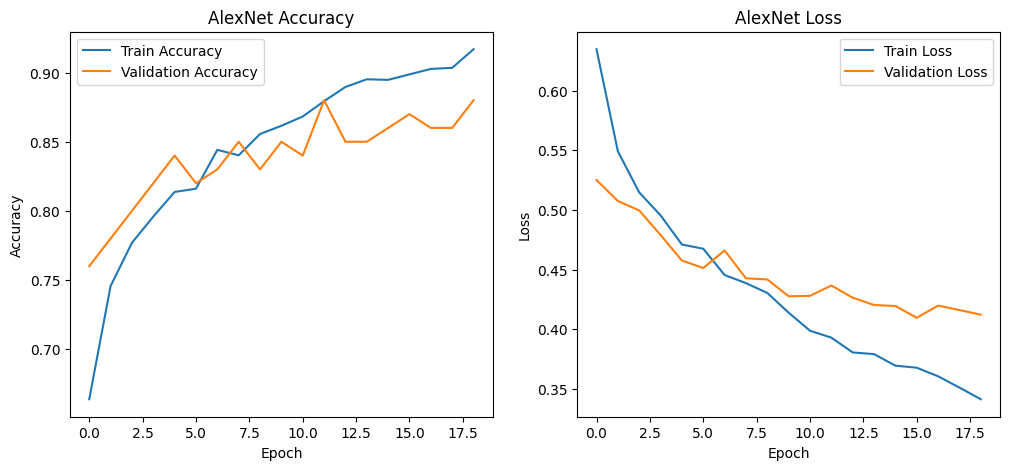

In [ ]:
# Evaluate AlexNet on the test set
print("Evaluating AlexNet on test set...")
alexnet_model.eval() # Set model to evaluation mode

alexnet_preds = []
alexnet_labels = []
correct = 0
total = 0

with torch.no_grad():
    for images, labels in alexnet_trainer.test_loader:
        images = images.to(alexnet_trainer.device)
        labels = labels.to(alexnet_trainer.device)

        outputs = alexnet_model(images)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        alexnet_preds.extend(preds.cpu().numpy())
        alexnet_labels.extend(labels.cpu().numpy())

alexnet_test_acc = correct / total
print(f"AlexNet Test Accuracy: {alexnet_test_acc:.4f}")

# Plotting Training History
history_available = (
    hasattr(alexnet_trainer, "train_accuracies") and
    hasattr(alexnet_trainer, "val_accuracies") and
    hasattr(alexnet_trainer, "train_losses") and
    hasattr(alexnet_trainer, "val_losses")
)

if history_available:
    plt.figure(figsize=(12,5))

    # Accuracy Plot
    plt.subplot(1,2,1)
    plt.plot(alexnet_trainer.train_accuracies, label="Train Accuracy")
    plt.plot(alexnet_trainer.val_accuracies, label="Validation Accuracy")
    plt.title("AlexNet Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss Plot
    plt.subplot(1,2,2)
    plt.plot(alexnet_trainer.train_losses, label="Train Loss")
    plt.plot(alexnet_trainer.val_losses, label="Validation Loss")
    plt.title("AlexNet Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()
else:
    print("⚠ Training history not found in trainer object for AlexNet.")


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        alexnet_labels,
        alexnet_preds,
        target_names=[
            "Autistic",
            "Non-Autistic"
        ],
        digits=4
    )
)

              precision    recall  f1-score   support

    Autistic     0.8023    0.9200    0.8571       150
Non-Autistic     0.9062    0.7733    0.8345       150

    accuracy                         0.8467       300
   macro avg     0.8543    0.8467    0.8458       300
weighted avg     0.8543    0.8467    0.8458       300



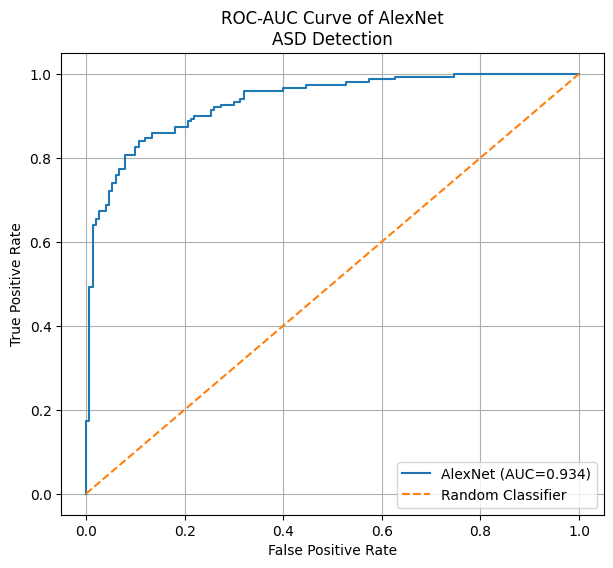

AlexNet ROC-AUC Score: 0.9336


In [ ]:
# ==========================================================
# AlexNet ROC-AUC Curve
# ==========================================================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc


fpr, tpr, thresholds = roc_curve(
    alexnet_labels,
    alexnet_probs
)


roc_auc = auc(
    fpr,
    tpr
)


plt.figure(figsize=(7,6))


plt.plot(
    fpr,
    tpr,
    label=f"AlexNet (AUC={roc_auc:.3f})"
)


plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random Classifier"
)


plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC-AUC Curve of AlexNet\nASD Detection"
)

plt.legend(
    loc="lower right"
)

plt.grid(True)

plt.show()


print(
    f"AlexNet ROC-AUC Score: {roc_auc:.4f}"
)

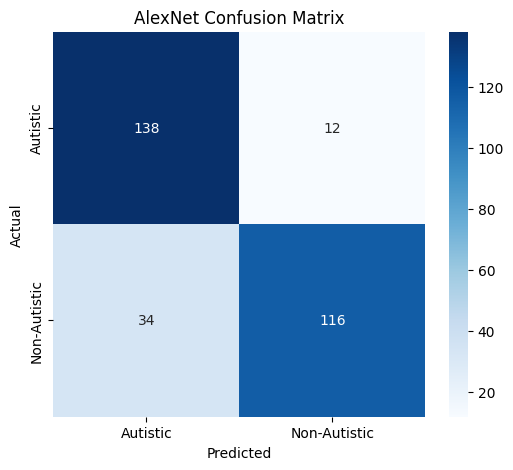

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(
    alexnet_labels,
    alexnet_preds
)


plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Autistic",
        "Non-Autistic"
    ],
    yticklabels=[
        "Autistic",
        "Non-Autistic"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "AlexNet Confusion Matrix"
)

plt.show()